# 🎵 Spotify Music Analysis — Exploratory Data Analysis

This notebook contains an exploratory data analysis of a Spotify tracks dataset 
covering 125 different genres. The goal is to identify patterns and insights about 
music trends, audio features, and genre characteristics.

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)  
**Author:** Emmanuel Mora Grajales  
**Tools:** Python, Pandas, Matplotlib

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

## 1. Loading the Data

In [2]:
# Load dataset
df = pd.read_csv('../data/dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (114000, 21)
Rows: 114,000
Columns: 21


In [3]:
# Preview first rows of the dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Check data types, null values and memory usage
print(df.info())

# Summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2. Data Cleaning

In [5]:
# Drop column "Unnamed: 0"

df = df.drop(columns='Unnamed: 0')

In [6]:
df.shape

(114000, 20)

In [7]:
# After dropping Unnamed: 0 column
print(f"Columns after dropping 'Unnamed: 0': {df.shape[1]}")

Columns after dropping 'Unnamed: 0': 20


In [8]:
# Drop NaN values

df = df.dropna()

In [9]:
# After dropping NaN values
print(f"Rows after dropping NaN values: {df.shape[0]:,}")

Rows after dropping NaN values: 113,999


In [10]:
# Verify duplicates

df.duplicated().sum()

np.int64(450)

In [11]:
# Drop duplicates

df = df.drop_duplicates()

In [12]:
# After dropping duplicates
print(f"Rows after dropping duplicates: {df.shape[0]:,}")

Rows after dropping duplicates: 113,549


## 3. Exploratory Data Analysis

### Business Questions
1. Which genres have the highest average popularity?
2. Which artists have the highest average popularity?
3. Do the most popular artists belong to the most popular genres?
4. Does an artist's popularity change if it's not a collaboration?
5. Do more energetic and danceable songs tend to be more popular?
6. Which genres have the highest average energy?
7. Are explicit songs more popular than non-explicit ones?
8. Does song duration influence popularity?
9. Does tempo influence popularity?
10. Do live songs have the same impact as instrumental or acoustic ones?
11. Do the most popular songs of an artist belong to the same album?
12. Does an explicit or danceable song necessarily have to be loud?

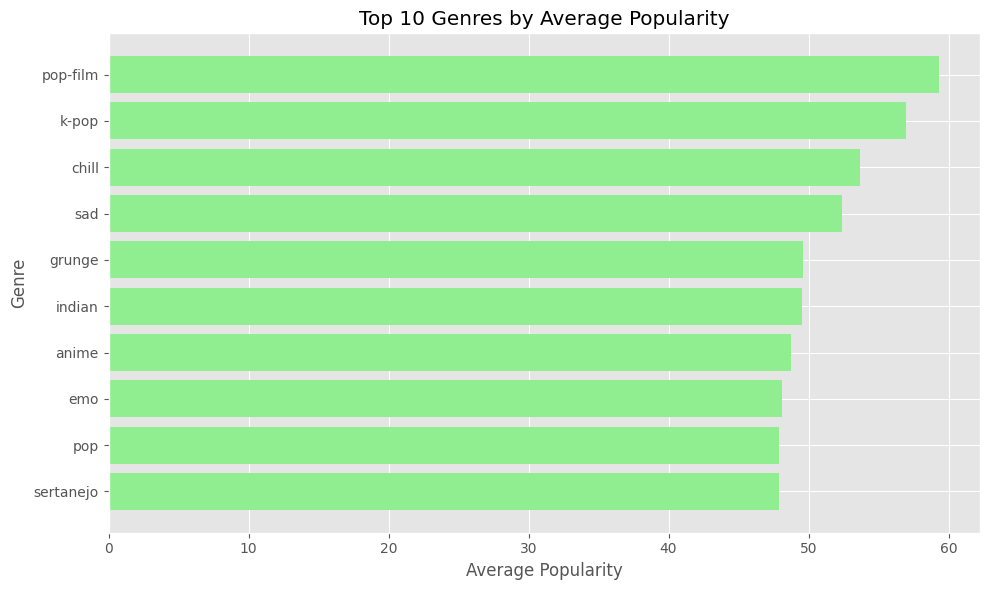

In [13]:
# 1. Which genres have the highest average popularity?

top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_genres.index[::-1] , top_genres.values[::-1] , color='lightgreen')

plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Insight
The most popular genre on average in the top chart is pop-film, with an average score close to 60, followed by K-pop, demonstrating its global impact. Surprisingly, the sad genre appears in the top 4 and the emo genre in the top 8, indicating that people listen to melancholic music quite frequently.



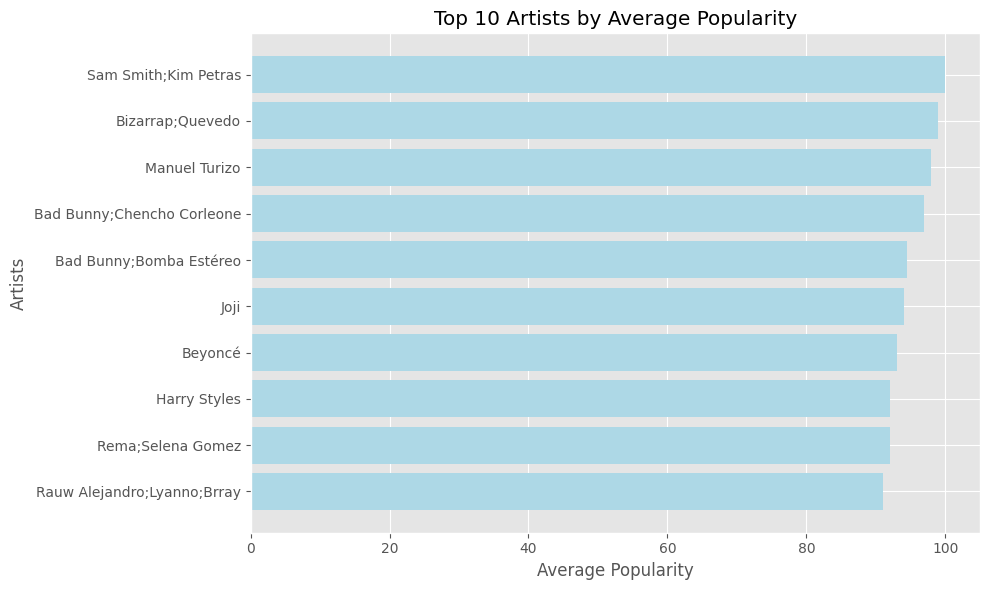

In [ ]:
# 2. Which artists have the highest average popularity?

top_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending = False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_artists.index[::-1] , top_artists.values[::-1] , color='lightblue')

plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.tight_layout()
plt.show()

### Insight

The most popular artists on this list are Sam Smith (collaboration with Kim Petras), followed by Bizarrap (collaboration with Quevedo) and Manuel Turizo, with an average close to 100. An interesting fact about this list is that most of the most popular artists collaborate with others.

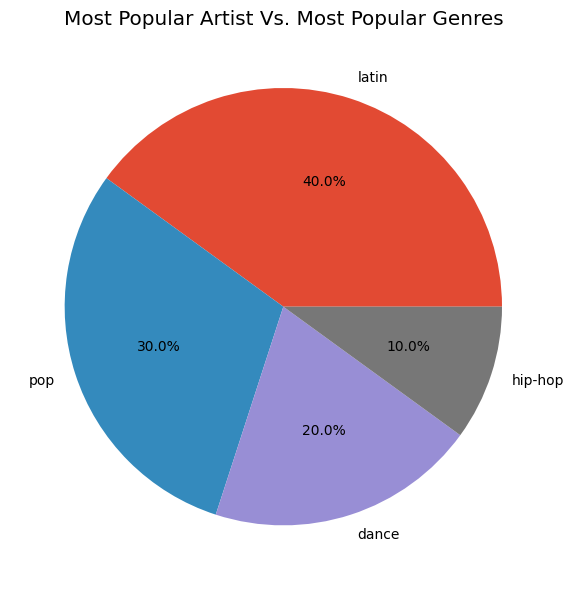

In [21]:
# 3. Do the most popular artists belong to the most popular genres?

# Filter tracks from top artists
top_artists_df = df[df['artists'].isin(top_artists.index)]

top_artists_track_genre = top_artists_df.groupby('artists')['track_genre'].first()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

genre_counts = top_artists_track_genre.value_counts()

ax.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%')

plt.title('Most Popular Artist Vs. Most Popular Genres')
plt.tight_layout()
plt.show()



### Insight
The most common genre among the top artists is Latin, representing 40% of the group, followed by Pop with 30%. Interestingly, none of these genres appear in the top 10 most popular genres from Question 1. This suggests that having popular artists does not necessarily mean the genre itself ranks high in average popularity — genre popularity and artist popularity are influenced by different factors.